## 3.1 基于Logisitic回归的二分类任务
### 3.1.1 数据集构建

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import math
import copy
import paddle

def make_moons(n_samples=1000, shuffle=True, noise=None):
    """
    生成带噪音的弯月形状数据
    输入:
        - n_samples: 数据量大小，数据类型为int
        - shuffle: 是否打乱数据，数据类型为bool
        - noise: 以多大的程度增加噪声，数据类型为None或float, noise为None时表示不增加噪声
    输出:
        - X: 特征数据, shape=[n_samples, 2]
        - y: 标签数据, shape=[n_samples]
    """
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out

    # 采集第一类数据，特征为(x, y)
    # 使用paddle.linspace在0到pi上均匀取n_samples_out个值
    # 使用paddle.cos计算上述取值的余弦值作为特征1，使用paddle.sin计算上述取值的正弦值作为特征2
    outer_circ_x = paddle.cos(paddle.linspace(0, math.pi, n_samples_out))
    outer_circ_y = paddle.sin(paddle.linspace(0, math.pi, n_samples_out))

    inner_circ_x = 1 - paddle.cos(paddle.linspace(0, math.pi, n_samples_in))
    inner_circ_y = 0.5 - paddle.sin(paddle.linspace(0, math.pi, n_samples_in))

    print("outer_circ_x.shape: ", outer_circ_x.shape, "outer_circ_y.shape: ", outer_circ_y.shape)
    print("inner_circ_x.shape: ", inner_circ_x.shape, "inner_circ_y.shape: ", inner_circ_y.shape)

    # 使用paddle.concat将两类数据的特征1和特征2分别沿维度0拼接在一起，得到全部特征1和特征2
    # 使用paddle.stack将两类特征沿维度1堆叠在一起

    X = paddle.stack(
        [paddle.concat([outer_circ_x, inner_circ_x]),
        paddle.concat([outer_circ_y, inner_circ_y])],
        axis=1
    )

    print("after concat shape: ", paddle.concat([outer_circ_x, inner_circ_x]).shape)
    print("X shape: ", X.shape)

    # 使用paddle.zeros 将第一类数据的标签全部设置为0
    # 使用paddle.ones 将第一类数据的标签全部设置为1
    y = paddle.concat(
        [paddle.zeros(shape=[n_samples_out]), paddle.ones(shape=[n_samples_in])]
    )

    print("y shape: ", y.shape)

    # 如果shuffle 为 True, 将所有数据打乱
    if shuffle:
        # 使用paddle.randperm生成一个数值在0到X.shape[0], 随机排列的一维Tensor做索引值，用于打乱数据
        idx = paddle.randperm(X.shape[0])
        X = X[idx]
        y = y[idx]

    # 如果noise不为None, 则给特征值加入噪声
    if noise is not None:
        # 使用paddle.normal 生成符合正态分布的随机Tensor作为噪声，并加到原始特征上
        X += paddle.normal(mean=0.0, std=noise, shape=X.shape)

    return X, y

outer_circ_x.shape:  [500] outer_circ_y.shape:  [500]
inner_circ_x.shape:  [500] inner_circ_y.shape:  [500]
after concat shape:  [1000]
X shape:  [1000, 2]
y shape:  [1000]


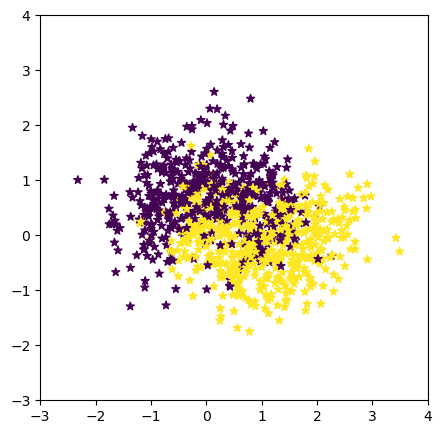

In [3]:
# 采样1000个样本
n_samples = 1000
X, y = make_moons(n_samples=n_samples, shuffle=True, noise=0.5)
# 可视化产生的数据集，不同颜色代表不同类别
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(x=X[:, 0].tolist(), y=X[:, 1].tolist(), marker="*", c=y.tolist())
plt.xlim(-3, 4)
plt.ylim(-3, 4)
# plt.savefig("linear-dataset_vis_noise_0p5.pdf")
plt.show()

In [4]:
num_train = 640
num_dev = 160
num_test = 200

X_train, y_train = X[:num_train], y[:num_train]
X_dev, y_dev = X[num_train: num_train+num_dev], y[num_train: num_train+num_dev]
X_test, y_test = X[num_train + num_dev:], y[num_train + num_dev:]

y_train = y_train.reshape([-1, 1])
y_dev = y_dev.reshape([-1, 1])
y_test = y_test.reshape([-1, 1])

In [5]:
# 打印X_train和y_train的维度
print("X_train shape: ", X_train.shape, "y_train shape: ", y_train.shape)

X_train shape:  [640, 2] y_train shape:  [640, 1]


In [6]:
# 打印一下前5个数据的标签
print(y_train[:5]) 

Tensor(shape=[5, 1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[1.],
        [1.],
        [1.],
        [0.],
        [0.]])


### 3.1.2 模型构建

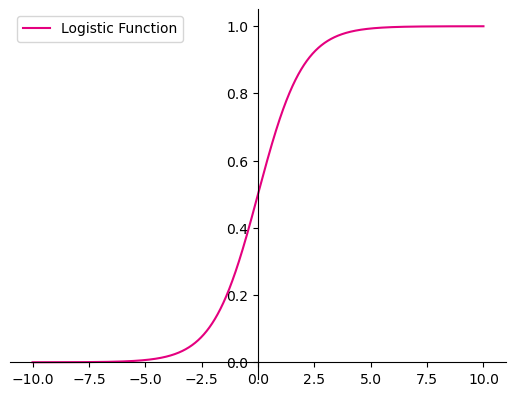

In [7]:
# 定义Logistic函数
def logistic(x):
    return 1 / (1+paddle.exp(-x))

# 在[-10, 10]的范围内生成一系列的输入值，用于绘制函数曲线
x = paddle.linspace(-10, 10, 10000)
plt.figure()
plt.plot(x.tolist(), logistic(x).tolist(), color="#e4007f", label="Logistic Function")

# 设置坐标轴
ax = plt.gca()
# 取消右侧和上侧坐标轴
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")
# 设置默认的x轴和y轴方向
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")

# 设置坐标原点为(0, 0)
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))

# 添加图例
plt.legend()
# plt.savefig("linear_logistic.pdf")
plt.show()

In [8]:
from nndl_study import op

class model_LR(op.Op):
    def __init__(self, input_dim):
        super(model_LR, self).__init__()
        self.params = {}
        # 将线性层的权重参数全部初始化为0
        self.params["w"] = paddle.zeros(shape=[input_dim, 1])
        # 将线性层的偏置参数初始化为0
        self.params["b"] = paddle.zeros(shape=[1])


    def __call__(self, inputs):
        return self.forward(inputs)


    def forward(self, inputs):
        """
        输入:
            - inputs: shape[N, D], N使样本数量，D为特征维度
        输出:
            - outputs: 预测标签为1的概率, shape = [N, 1]
        """
        # 线性计算
        score = paddle.matmul(inputs, self.params["w"]) + self.params["b"]
        # Logistic 函数
        outputs = logistic(score)
        return outputs

In [9]:
# 固定随机种子，保持每次运行结果一致
paddle.seed(0)
# 随机生成3条长度为4的数据
inputs = paddle.randn(shape=[3, 4])
print("Input is: ", inputs)
# 实例化模型
model = model_LR(4)
outputs = model(inputs)
print("Output is: ", outputs)

Input is:  Tensor(shape=[3, 4], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[-0.38059190, -0.75711036,  1.34467661,  0.10946669],
        [-1.27341712, -0.84002435,  0.14070207,  2.47224617],
        [ 0.23396523,  0.60608417,  0.10350471,  1.35604191]])
Output is:  Tensor(shape=[3, 1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[0.50000000],
        [0.50000000],
        [0.50000000]])


### 3.1.3 损失函数

In [10]:
# 实现交叉熵损失函数
class BinaryCrossEntropyLoss(op.Op):
    def __init__(self):
        self.predicts = None
        self.labels = None
        self.num = None

    def __call__(self, predicts, labels):
        return self.forward(predicts, labels)

    def forward(self, predicts, labels):
        """
        输入:
            - predicts: 预测值，shape=[N, 1], N为样本数量
            - labels: 真实标签, shape=[N ,1]
        输出:
            - 损失值: shape=[1]
        """
        self.predicts = predicts
        self.labels = labels
        self.num = self.predicts.shape[0]
        loss = -1. / self.num * (paddle.matmul(self.labels.t(), paddle.log(self.predicts)) + paddle.matmul((1-self.labels.t()), paddle.log(1-self.predicts)))
        loss = paddle.squeeze(loss, axis=1)
        return loss


# 测试一下
# 生成一组长度为3, 值为1的标签数据
labels = paddle.ones(shape=[3, 1])
# 计算风险函数
bce_loss = BinaryCrossEntropyLoss()
print(bce_loss(outputs, labels))

Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=True,
       [0.69314718])


### 3.1.4 模型优化
#### 3.1.4.1 梯度计算

In [11]:
class model_LR(op.Op):
    def __init__(self, input_dim):
        super(model_LR, self).__init__()
        # 存放线性层参数
        self.params = {}
        # 将线性层的权重参数全部初始化为0
        self.params["w"] = paddle.zeros(shape=[input_dim, 1])
        # self.params["w"] = paddle.normal(mean=0, std=0.01, shape=[input_dim, 1])
        # 将线性层的偏置参数初始化为0
        self.params["b"] = paddle.zeros(shape=[1])
        # 存放参数的梯度
        self.grads = {}
        self.X = None
        self.outputs = None

    def __call__(self, inputs):
        return self.forward(inputs)

    def forward(self, inputs):
        self.X = inputs
        # 线性计算
        score = paddle.matmul(inputs, self.params["w"]) + self.params["b"]
        # Logistic 函数
        self.outputs = logistic(score)
        return self.outputs

    def backward(self, labels):
        """
        输入:
            - labels: 真实标签, shape=[N, 1]
        """
        N = labels.shape[0]
        # 计算偏导数
        self.grads["w"] = -1 / N * paddle.matmul(self.X.t(), (labels - self.outputs))
        self.grads["b"] = -1 / N * paddle.sum(labels - self.outputs)

#### 3.1.4.2 参数更新

In [12]:
from abc import abstractmethod

# 优化器基类
class Optimizer(object):
    def __init__(self, init_lr, model):
        """
        优化器类初始化
        """
        # 初始化学习率，用于参数更新的计算
        self.init_lr = init_lr
        # 指定优化器需要优化的模型
        self.model = model

    @abstractmethod
    def step(self):
        """
        定义每次迭代如何更新参数
        """
        pass

In [13]:
class SimpleBatchGD(Optimizer):
    def __init__(self, init_lr, model):
        super(SimpleBatchGD, self).__init__(init_lr=init_lr, model=model)

    def step(self):
        # 参数更新
        # 遍历所有参数，按照公式更新参数
        if isinstance(self.model.params, dict):
            for key in self.model.params.keys():
                self.model.params[key] = self.model.params[key] - self.init_lr * self.model.grads[key]

### 3.1.5 评价指标

In [14]:
def accuracy(preds, labels):
    """
    输入:
        - preds: 预测值, 二分类时, shape=[N, 1], N为样本数量, 多分类时, shape=[N, C], C为类别数量
        - labels: 真实标签, shape=[N, 1]
    输出:
        - 准确率: shape=[1]
    """
    # 判断是二分类任务还是多分类任务, preds.shape[1]=1时为二分类任务, preds.shape[1]>1时为多分类任务
    if preds.shape[1] == 1:
        # 二分类时，判断每个概率值是否大于0.5, 当大于0.5时, 类别为1, 否则类别为0
        # 使用paddle.cast将preds的数据类型转换为float32类型
        preds = paddle.cast((preds>=0.5), dtype="float32")
    else:
        # 多分类时, 使用paddle.argmax计算最大元素索引作为类别
        preds = paddle.argmax(preds, axis=1, dtype="int32")
    return paddle.mean(paddle.cast(paddle.equal(preds, labels), dtype="float32"))


# 假设模型的预测值为[[0.], [1.], [1.], [0.]], 真实类别为[[1.], [1.], [0.], [0.]], 计算准确率
preds = paddle.to_tensor([[0.], [1.], [1.], [0.]])
labels = paddle.to_tensor([[1.], [1.], [0.], [0.]])
print("accuracy is: ", accuracy(preds, labels))

accuracy is:  Tensor(shape=[], dtype=float32, place=Place(cpu), stop_gradient=True,
       0.50000000)


### 3.1.6 完善Runner类

In [15]:
# 用RunnerV2类封装整个训练过程
class RunnerV2(object):
    def __init__(self, model, optimizer, metric, loss_fn):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metric = metric

        # 记录训练过程中的评价指标变化情况
        self.train_scores = []
        self.dev_scores = []
        # 记录训练过程中的损失函数变化情况
        self.train_loss = []
        self.dev_loss = []

    def train(self, train_set, dev_set, **kwargs):
        # 传入训练轮数，如果没有传入值则默认为0
        num_epochs = kwargs.get("num_epochs", 0)
        # 传入log打印频率, 如果没有传入值则默认为100
        log_epochs = kwargs.get("log_epochs", 100)
        # 传入模型保存路径, 如果没有传入值则默认为"best_model.pdparams"
        save_path = kwargs.get("save_path", "best_model.pdparams")
        # 梯度打印函数, 如果没有传入值则默认为"None"
        print_grads = kwargs.get("print_grads", None)
        # 记录全局最优指标
        best_score = 0

        # 进行num_epochs轮训练
        for epoch in range(num_epochs):
            X, y = train_set
            # 获取模型预测
            logits = self.model(X)
            # 计算交叉熵损失
            trn_loss = self.loss_fn(logits, y).item()
            self.train_loss.append(trn_loss)
            # 计算评价指标
            trn_score = self.metric(logits, y).item()
            self.train_scores.append(trn_score)
            # 计算参数梯度
            self.model.backward(y)
            if print_grads is not None:
                # 打印每一层的梯度
                print_grads(self.model)

            # 更新模型参数
            self.optimizer.step()
            dev_score, dev_loss = self.evaluate(dev_set)
            # 如果当前指标为最优指标, 保存该模型
            if dev_score > best_score:
                self.save_model(save_path)
                print(f"best accuracy performence has been updated: {best_score:.5f} --> {dev_score:.5f}")
                best_score = dev_score
            if epoch % log_epochs == 0:
                print(f"[Train] epoch: {epoch}, loss: {trn_loss}, score: {trn_score}")
                print(f"[Dev] epoch: {epoch}, loss: {dev_loss}, score: {dev_score}")


    def evaluate(self, data_set):
        X, y = data_set
        # 计算模型输出
        logits = self.model(X)
        # 计算损失函数
        loss = self.loss_fn(logits, y).item()
        self.dev_loss.append(loss)
        # 计算评价指标
        score = self.metric(logits, y).item()
        self.dev_scores.append(score)
        return score, loss


    def predict(self, X):
        return self.model(X)

    def save_model(self, save_path):
        paddle.save(self.model.params, save_path)

    def load_model(self, model_path):
        self.model.params = paddle.load(model_path)

### 3.1.7 模型训练

In [16]:
# 固定速记种子，保持每次运行结果一致
paddle.seed(102)

# 特征维度
input_dim = 2
# 学习率
lr = 0.1

# 实例化模型
model = model_LR(input_dim=input_dim)
# 指定优化器
optimizer = SimpleBatchGD(init_lr=lr, model=model)
# 指定损失函数
loss_fn = BinaryCrossEntropyLoss()
# 指定评价方式
metric = accuracy

# 实例化RunnerV2类, 并传入训练配置
runner = RunnerV2(model, optimizer, metric, loss_fn)

runner.train([X_train, y_train], [X_dev, y_dev], num_epochs=500, log_epochs=50, save_path="best_model.pdparams")

best accuracy performence has been updated: 0.00000 --> 0.76250
[Train] epoch: 0, loss: 0.6931473016738892, score: 0.5078125
[Dev] epoch: 0, loss: 0.6845338940620422, score: 0.762499988079071
best accuracy performence has been updated: 0.76250 --> 0.76875
[Train] epoch: 50, loss: 0.5037071108818054, score: 0.7734375
[Dev] epoch: 50, loss: 0.5093426704406738, score: 0.768750011920929
best accuracy performence has been updated: 0.76875 --> 0.77500
best accuracy performence has been updated: 0.77500 --> 0.78125
[Train] epoch: 100, loss: 0.46668729186058044, score: 0.784375011920929
[Dev] epoch: 100, loss: 0.4692746102809906, score: 0.7749999761581421
[Train] epoch: 150, loss: 0.45392274856567383, score: 0.78125
[Dev] epoch: 150, loss: 0.45306578278541565, score: 0.768750011920929
[Train] epoch: 200, loss: 0.4483194351196289, score: 0.784375011920929
[Dev] epoch: 200, loss: 0.4445905387401581, score: 0.7749999761581421
[Train] epoch: 250, loss: 0.44550538063049316, score: 0.784375011920929

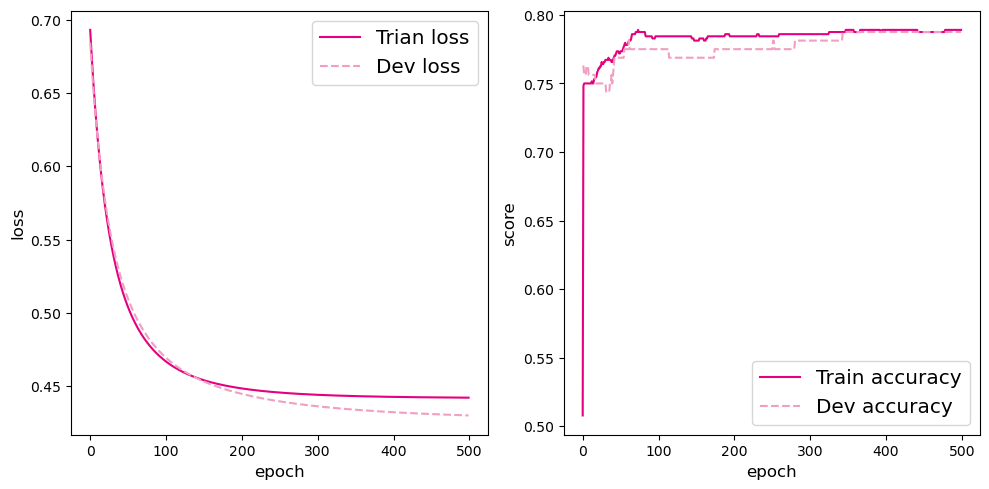

In [17]:
# 可视化观察训练集与验证集的指标变化情况
def plot(runner, fig_name):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    epochs = [i for i in range(len(runner.train_scores))]

    # 绘制训练损失变化曲线
    plt.plot(epochs, runner.train_loss, color="#e4007f", label="Trian loss")
    # 绘制评价损失变化曲线
    # print(f"epochs: {epochs}")
    # print(f"runner.dev_loss: {len(runner.dev_loss)}")
    plt.plot(epochs, runner.dev_loss, color="#f19ec2", linestyle="--", label="Dev loss")

    # 绘制坐标轴和图例
    plt.ylabel("loss", fontsize="large")
    plt.xlabel("epoch", fontsize="large")
    plt.legend(loc="upper right", fontsize="x-large")

    plt.subplot(1, 2, 2)
    # 绘制训练准确率变化曲线
    plt.plot(epochs, runner.train_scores, color="#e4007f", label="Train accuracy")
    # 绘制评价准确率变化曲线
    plt.plot(epochs, runner.dev_scores, color="#f19ec2", linestyle="--", label="Dev accuracy")
    # 绘制坐标轴和图例
    plt.ylabel("score", fontsize="large")
    plt.xlabel("epoch", fontsize="large")
    plt.legend(loc="lower right", fontsize="x-large")
    plt.tight_layout()
    # plt.savefig(fig_name)
    plt.show()


plot(runner, fig_name="linear-acc.pdf")

### 3.1.8 模型评价

In [18]:
score, loss = runner.evaluate([X_test, y_test])
print("[Test] score/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] score/loss: 0.8000/0.4638


In [19]:
def decision_boundary(w, b, x1):
    w1, w2 = w
    x2 = (- w1 * x1 - b) / w2
    return x2

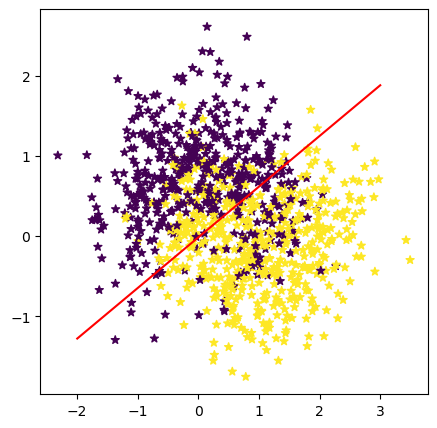

In [20]:
plt.figure(figsize=(5, 5))
# 绘制原始数据
plt.scatter(X[:, 0].tolist(), X[:, 1].tolist(), marker="*", c=y.tolist())

w = model.params["w"]
b = model.params["b"]
x1 = paddle.linspace(-2, 3, 1000)
x2 = decision_boundary(w, b, x1)
# 绘制决策边界
plt.plot(x1.tolist(), x2.tolist(), color="red")
plt.show()

## 3.2 基于Softmax回归的多分类任务
### 3.2.1 数据集构建

In [21]:
import numpy as np
import paddle

def make_multiclass_classification(n_samples=100, n_features=2, 
                                   n_classes=3, shuffle=True, noise=0.1):
    """
    生成带噪音的多类别数据
    输入:
        - n_samples: 数据量大小, 数据类型为int
        - n_features: 特征数量, 数据类型为int
        - shuffle: 是否打乱数据, 数据类型为bool
        - noise: 以多大的程度增加噪声, 数据类型为None或float
        noise 为 None 时表示不增加噪声
    输出:
        - X: 特征数据, shape=[n_samples, 2]
        - y: 标签数据, shape=[n_samples, 1]
    """
    # 计算每个类别的样本数量
    n_samples_per_class = [int(n_samples / n_classes) for k in range(n_classes)]
    for i in range(n_samples - sum(n_samples_per_class)):
        n_samples_per_class[i % n_classes] += 1

    # 将特征和标签初始化为0
    X = paddle.zeros([n_samples, n_features])
    y = paddle.zeros([n_samples], dtype="int32")

    # 随机生成3个簇中心作为类别中心
    centroids = paddle.randperm(2 ** n_features)[:n_classes]
    centroids_bin = np.unpackbits(centroids.numpy().astype("uint8")
                                 ).reshape((-1, 8))[:, -n_features:]
    centroids = paddle.to_tensor(centroids_bin, dtype="float32")

    # 控制簇中心的分离程度
    centroids = 1.6 * centroids - 1
    # 随机生成特征值
    X[:, :n_features] = paddle.randn(shape=[n_samples, n_features])

    stop = 0

    # 将每个类的特征值控制在簇中心附近
    for k, centroid in enumerate(centroids):
        start, stop = stop, stop + n_samples_per_class[k]
        # 指定标签值
        y[start: stop] = k % n_classes
        X_k = X[start: stop, :n_features]

        # 控制每个类别特征值的分散程度
        A = 2 * paddle.rand(shape=[n_features, n_features]) - 1
        X_k[...] = paddle.matmul(X_k, A)
        X_k += centroid
        X[start: stop, :n_features] = X_k

    # 如果noise 不为None, 则给特征加入噪声
    if noise > 0.0:
        # 生成noise掩膜, 用来指定给那些样本加入噪声
        noise_mask = paddle.rand([n_samples]) < noise
        for i in range(len(noise_mask)):
            if noise_mask[i]:
                # 给加噪声的样本随机赋标签值
                y[i] = paddle.randint(n_classes, shape=[1]).astype("int32")

    # 如果shuffle为True, 将所有数据打乱
    if shuffle:
        idx = paddle.randperm(X.shape[0])
        X = X[idx]
        y = y[idx]

    return X, y

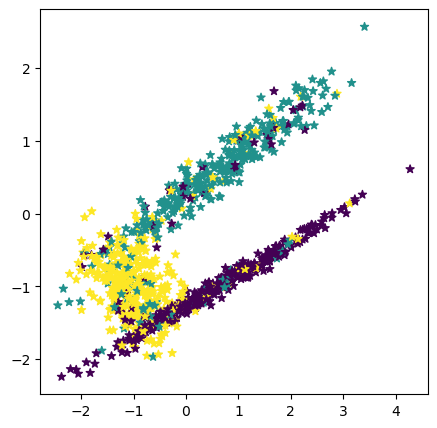

In [22]:
# 固定随机种子, 保持每次运行结果一致
paddle.seed(102)
# 采样1000个样本
n_samples = 1000
X, y = make_multiclass_classification(n_samples=n_samples, n_features=2, n_classes=3,
                                     noise=0.2)

# 可视化生成的数据集，不同颜色代表不同类别
plt.figure(figsize=(5, 5))
plt.scatter(x=X[:, 0].tolist(), y=X[:, 1].tolist(), marker="*", c=y.tolist())
# plt.savefig("linear-dataset-vis2.pdf")
plt.show()

In [23]:
num_train = 640
num_dev = 160
num_test = 200

X_train, y_train = X[: num_train], y[: num_train]
X_dev, y_dev = X[num_train: num_train+num_dev], y[num_train: num_train + num_dev]
X_test, y_test = X[num_train + num_dev:], y[num_train + num_dev:]

# 打印X_train 和 y_train 的维度
print("X_train shape: ", X_train.shape, "y_train shape: ", y_train.shape)

X_train shape:  [640, 2] y_train shape:  [640]


In [24]:
# 打印前5个数据的标签
print(y_train[:5])

Tensor(shape=[5], dtype=int32, place=Place(cpu), stop_gradient=True,
       [0, 0, 2, 2, 0])


### 3.2.2 模型构建
#### 3.2.2.1 Softmax函数

In [25]:
# x 为tensor
def softmax(X):
    """
    输入:
        - X: shape=[N, C], N为向量数量, C为向量维度
    """
    x_max = paddle.max(X, axis=1, keepdim=True)  # N, 1
    x_exp = paddle.exp(X - x_max)
    partition = paddle.sum(x_exp, axis=1, keepdim=True)  # N, 1
    return x_exp / partition


# 观察softmax的计算方式
X = paddle.to_tensor([[0.1, 0.2, 0.3, 0.4], [1, 2, 3, 4]])
predict = softmax(X)
print(predict)

Tensor(shape=[2, 4], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[0.21383820, 0.23632778, 0.26118258, 0.28865141],
        [0.03205860, 0.08714432, 0.23688281, 0.64391422]])


#### 3.2.2.2 Softmax回归算子

In [26]:
class model_SR(op.Op):
    def __init__(self, input_dim, output_dim):
        super(model_SR, self).__init__()
        self.params = {}
        # 将线性层的权重参数全部初始化为 0 
        self.params["w"] = paddle.zeros(shape=[input_dim, output_dim])
        # self.params["w"] = paddle.normal(mean=0, std=0.01, shape=[input_dim, output_dim])
        # 将线性层的偏置参数初始化为0
        self.params["b"] = paddle.zeros(shape=[output_dim])
        self.outputs = None


    def __call__(self, inputs):
        return self.forward(inputs)


    def forward(self, inputs):
        """
        输入:
            - inputs: shape=[N, D], N是样本数量, D是特征维度
        输出:
            - outputs: 预测值, shape=[N, C], C时类别数
        """
        # 线性计算
        score = paddle.matmul(inputs, self.params["w"]) + self.params["b"]
        # Softmax函数
        self.outputs = softmax(score)
        return self.outputs


# 随机生成一条长度为4的数据
inputs = paddle.randn(shape=[1, 4])
print("Input is: ", inputs)
# 实例化模型, 这里令输入长度为4，输出类别数为3
model = model_SR(input_dim=4, output_dim=3)
outputs = model(inputs)
print("Output is: ", outputs)

Input is:  Tensor(shape=[1, 4], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[ 0.87384248, -1.39146304, -0.19708443, -2.12604046]])
Output is:  Tensor(shape=[1, 3], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[0.33333334, 0.33333334, 0.33333334]])


### 3.2.3 损失函数

In [27]:
class MultiCrossEntropyLoss(op.Op):
    def __init__(self):
        self.predicts = None
        self.labels = None
        self.num = None


    def __call__(self, predicts, labels):
        return self.forward(predicts, labels)

    
    def forward(self, predicts, labels):
        """
        输入:
            - predicts: 预测值, shape=[N, 1], N为样本数量
            - labels: 真实标签, shape=[N, 1]
        输出:
            - 损失值: shape=[1]
        """
        self.predicts = predicts
        self.labels = labels
        self.num = self.predicts.shape[0]
        loss = 0
        for i in range(0, self.num):
            index = self.labels[i]
            loss -= paddle.log(self.predicts[i][index])
        return loss / self.num


# 测试一下
# 假设真实标签为第一类
labels = paddle.to_tensor([0])
# 计算风险函数
mce_loss = MultiCrossEntropyLoss()
print(mce_loss(outputs, labels))

Tensor(shape=[], dtype=float32, place=Place(cpu), stop_gradient=True,
       1.09861231)


### 3.2.4 模型优化
#### 3.2.4.1 梯度计算

In [32]:
class model_SR(op.Op):
    def __init__(self, input_dim, output_dim):
        super(model_SR, self).__init__()
        self.params = {}
        # 将线性层的权重参数全部初始化为0
        self.params["W"] = paddle.zeros(shape=[input_dim, output_dim])
        # self.params["W"] = paddle.normal(mean=0, std=0.01, shape=[input_dim, output_dim])
        # 将线性层的偏置参数初始化为0
        self.params["b"] = paddle.zeros(shape=[output_dim])
        # 存放参数的梯度
        self.grads = {}
        self.X = None
        self.outputs = None
        self.output_dim = output_dim


    def __call__(self, inputs):
        return self.forward(inputs)


    def forward(self, inputs):
        self.X = inputs
        # 线性计算
        score = paddle.matmul(self.X, self.params["W"]) + self.params["b"]
        # Softmax 函数
        self.outputs = softmax(score)
        return self.outputs


    def backward(self, labels):
        """
        输入:
            - labels: 真实标签, shape=[N, 1], 其中N为样本数量
        """
        # 计算偏导数
        N = labels.shape[0]
        labels = paddle.nn.functional.one_hot(labels, self.output_dim)
        self.grads["W"] = -1 / N * paddle.matmul(self.X.t(), (labels-self.outputs))
        self.grads["b"] = -1 / N * paddle.matmul(paddle.ones(shape=[N]), 
                                                (labels-self.outputs))

#### 3.2.4.2 参数更新
### 3.2.5 模型训练

best accuracy performence has been updated: 0.00000 --> 0.70625
[Train] epoch: 0, loss: 1.098615050315857, score: 0.31562501192092896
[Dev] epoch: 0, loss: 1.0729466676712036, score: 0.706250011920929
best accuracy performence has been updated: 0.70625 --> 0.71250
best accuracy performence has been updated: 0.71250 --> 0.71875
best accuracy performence has been updated: 0.71875 --> 0.72500
best accuracy performence has been updated: 0.72500 --> 0.73125
best accuracy performence has been updated: 0.73125 --> 0.73750
best accuracy performence has been updated: 0.73750 --> 0.74375
best accuracy performence has been updated: 0.74375 --> 0.75000
best accuracy performence has been updated: 0.75000 --> 0.75625
best accuracy performence has been updated: 0.75625 --> 0.76250
best accuracy performence has been updated: 0.76250 --> 0.76875
[Train] epoch: 50, loss: 0.7681310176849365, score: 0.7671874761581421
[Dev] epoch: 50, loss: 0.7356626391410828, score: 0.762499988079071
best accuracy perfor

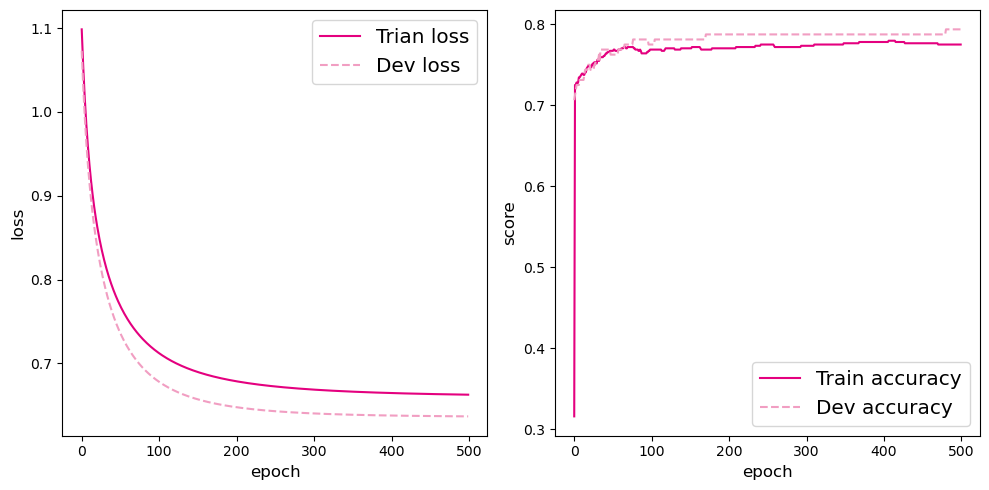

In [33]:
# 固定随机种子，保持每次运行结果一致
paddle.seed(102)

# 特征维度
input_dim = 2
# 类别数
output_dim = 3
# 学习数
lr = 0.1

# 实例化模型
model = model_SR(input_dim=input_dim, output_dim=output_dim)
# 指定优化器
optimizer = SimpleBatchGD(init_lr=lr, model=model)
# 指定损失函数
loss_fn = MultiCrossEntropyLoss()
# 指定评价方式
metric = accuracy
# 实例化RunnerV2类
runner = RunnerV2(model, optimizer, metric, loss_fn)

# 模型训练
runner.train([X_train, y_train], [X_dev, y_dev], num_epochs=500, log_epochs=50, 
            eval_epoch=1, save_path="best_model.pdparams")

# 可视化观察训练集与验证集的准确率变化情况
plot(runner, fig_name="linear-acc2.pdf")

### 3.2.6 模型评价

In [35]:
score, loss = runner.evaluate([X_test, y_test])
print("[Test] score/loss: {:.4f}/{:.4f}".format(score, loss))

[Test] score/loss: 0.7350/0.7515


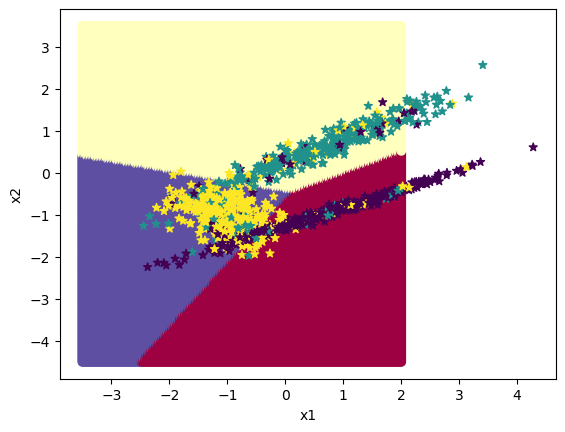

In [36]:
# 均匀生成400_00个数据点
x1, x2 = paddle.meshgrid(paddle.linspace(-3.5, 2, 200), paddle.linspace(-4.5, 3.5, 200))
x = paddle.stack([paddle.flatten(x1), paddle.flatten(x2)], axis=1)

# 预测对应类别
y = runner.predict(x)
y = paddle.argmax(y, axis=1)

# 绘制类别区域
plt.ylabel("x2")
plt.xlabel("x1")
plt.scatter(x[:, 0].tolist(), x[:, 1].tolist(), c=y.tolist(), cmap=plt.cm.Spectral)

paddle.seed(102)
n_samples = 1000
X, y = make_multiclass_classification(n_samples=n_samples, n_features=2, n_classes=3,
                                     noise=0.2)

plt.scatter(X[:, 0].tolist(), X[:, 1].tolist(), marker="*", c=y.tolist())